# 01 — Data Collection & Feature Engineering

This notebook:

1. Downloads SPY daily OHLCV via `yfinance` (2004-present)
2. Loads supplementary data: CBOE put/call ratio, AAII sentiment
3. Applies all feature engineering transforms
4. Performs a chronological train/val/test split
5. Saves the processed dataset to `data/processed/`

**Supplementary data — manual steps required:**

- Put/call ratio: download from https://www.cboe.com/us/options/market_statistics/daily/  
  Save as `data/raw/put_call_ratio.csv`
- AAII sentiment: download from https://www.aaii.com/sentimentsurvey/sent_results  
  Save as `data/raw/aaii_sentiment.csv`

The pipeline will proceed without these files (producing NaN columns) and
will warn you where they are missing.


In [1]:
import sys

sys.path.insert(0, "..")

import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils import setup_logging

setup_logging()

from config import (
    TICKER,
    START_DATE,
    END_DATE,
    TRAIN_END,
    VAL_END,
    VOL_WINDOW,
    ROLLING_WINDOWS,
    DATA_RAW,
    DATA_PROCESSED,
)

print("Config loaded.")
print(f"  Ticker      : {TICKER}")
print(f'  Date range  : {START_DATE} → {END_DATE or "today"}')
print(f"  Train end   : {TRAIN_END}")
print(f"  Val end     : {VAL_END}")
print(f"  Vol window  : {VOL_WINDOW} days")

Config loaded.
  Ticker      : SPY
  Date range  : 2001-04-01 → today
  Train end   : 2015-12-31
  Val end     : 2020-04-30
  Vol window  : 21 days


## 1. Download SPY OHLCV


In [2]:
from src.data_loader import download_spy

ohlcv = download_spy(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    raw_dir=DATA_RAW,
    force_refresh=True,
)

print(f"OHLCV shape: {ohlcv.shape}")
print(f"Date range : {ohlcv.index.min().date()} → {ohlcv.index.max().date()}")
print(f"Trading days: {len(ohlcv)}")
ohlcv.tail()

21:38:04 | INFO    | src.data_loader | Downloading SPY OHLCV from Yahoo Finance (2001-04-01 → today)…


21:38:05 | INFO    | src.data_loader | Cached SPY OHLCV → /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/raw/SPY_ohlcv.parquet


OHLCV shape: (6302, 5)
Date range : 2001-04-02 → 2026-04-23
Trading days: 6302


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-04-17,706.140015,712.390015,705.760010,710.140015,70661900
2026-04-20,708.780029,709.909973,706.140015,708.719971,43546800
2026-04-21,710.280029,711.280029,702.640015,704.080017,58941400
2026-04-22,709.150024,711.450012,708.219971,711.210022,42518500
2026-04-23,709.500000,712.359985,702.280029,708.450012,56047300


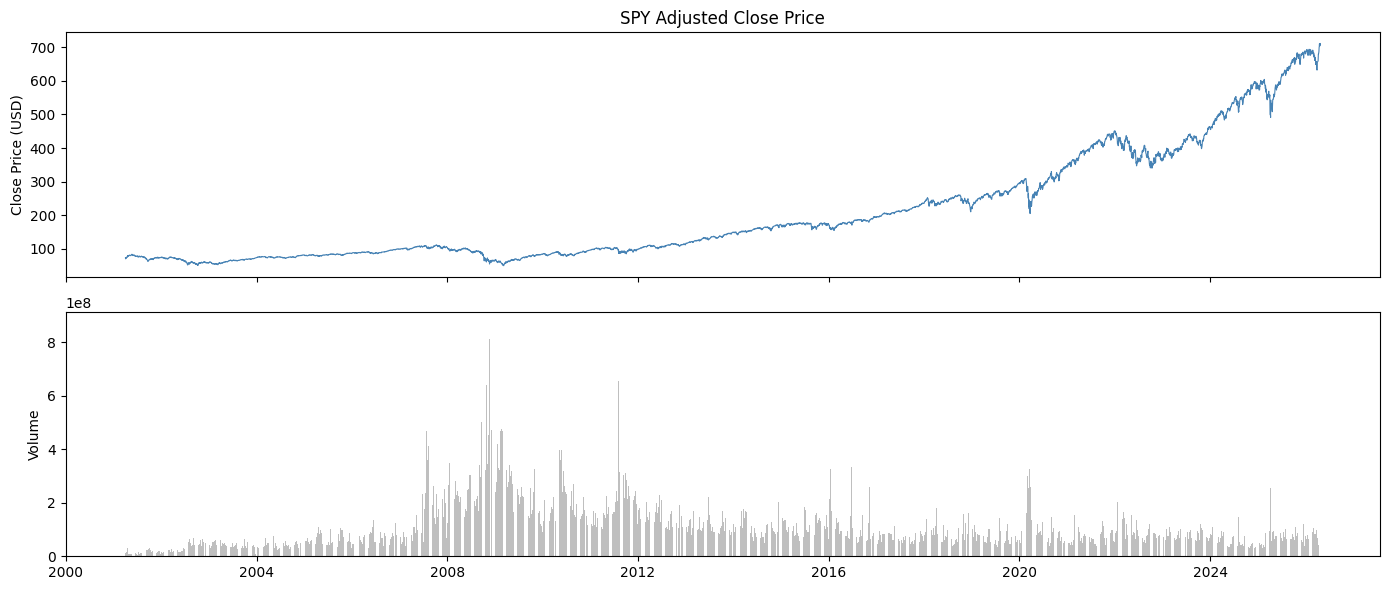

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(ohlcv.index, ohlcv["Close"], linewidth=0.8, color="steelblue")
axes[0].set_ylabel("Close Price (USD)")
axes[0].set_title("SPY Adjusted Close Price")
axes[1].bar(ohlcv.index, ohlcv["Volume"], width=1, color="gray", alpha=0.5)
axes[1].set_ylabel("Volume")
plt.tight_layout()
plt.show()

## 2. Load supplementary data


In [4]:
from src.data_loader import load_putcall_ratio, load_aaii_sentiment

pc_ratio = load_putcall_ratio(raw_dir=DATA_RAW)
sentiment = load_aaii_sentiment(raw_dir=DATA_RAW)

if pc_ratio.empty:
    print("⚠ Put/call ratio not found — will proceed without it.")
else:
    print(
        f"Put/call ratio: {len(pc_ratio)} rows, {pc_ratio.index.min().date()} → {pc_ratio.index.max().date()}"
    )

if sentiment.empty:
    print("⚠ AAII sentiment not found — will proceed without it.")
else:
    print(
        f"AAII sentiment: {len(sentiment)} rows, {sentiment.index.min().date()} → {sentiment.index.max().date()}"
    )
    print(sentiment.tail())

21:38:07 | WARNING | src.data_loader | Put/call ratio CSV not found. Download from https://www.cboe.com/us/options/market_statistics/daily/ and save as data/raw/put_call_ratio.csv


⚠ Put/call ratio not found — will proceed without it.
AAII sentiment: 2023 rows, 1987-06-26 → 2026-04-23
             bullish   bearish   neutral  bull_bear_spread
date                                                      
2026-03-26  0.320988  0.497942  0.181070         -0.176954
2026-04-02  0.335714  0.514286  0.150000         -0.178572
2026-04-09  0.357466  0.429864  0.212670         -0.072398
2026-04-16  0.317308  0.427885  0.254808         -0.110577
2026-04-23  0.460465  0.344186  0.195349          0.116279


## 3. Build the merged raw dataset


In [5]:
from src.data_loader import build_raw_dataset

raw_df = build_raw_dataset(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    raw_dir=DATA_RAW,
    processed_dir=DATA_PROCESSED,
)

print(f"\nRaw dataset shape: {raw_df.shape}")
print("Columns:", raw_df.columns.tolist())
print("\nMissing values:")
print(raw_df.isnull().sum()[raw_df.isnull().sum() > 0])
raw_df.tail()

21:38:07 | INFO    | src.data_loader | Loading SPY OHLCV from cache: /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/raw/SPY_ohlcv.parquet


21:38:07 | INFO    | src.data_loader | Downloading VIX family (VIXCLS, VXVCLS) from FRED…


21:38:09 | INFO    | src.data_loader | Cached VIX family → /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/raw/vix_family.parquet


21:38:09 | WARNING | src.data_loader | Put/call ratio CSV not found. Download from https://www.cboe.com/us/options/market_statistics/daily/ and save as data/raw/put_call_ratio.csv


21:38:09 | INFO    | src.data_loader | Missing data per column (%): 
vix       0.015868
vix3m    26.626468


21:38:09 | INFO    | src.data_loader | Saved merged raw dataset → /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/processed/raw_dataset.parquet



Raw dataset shape: (6302, 11)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'vix', 'vix3m', 'bullish', 'bearish', 'neutral', 'bull_bear_spread']

Missing values:
vix         1
vix3m    1678
dtype: int64


,Open,High,Low,Close,Volume,vix,vix3m,bullish,bearish,neutral,bull_bear_spread
Date,,,,,,,,,,,
2026-04-17,706.140015,712.390015,705.760010,710.140015,70661900,17.48,20.51,0.317308,0.427885,0.254808,-0.110577
2026-04-20,708.780029,709.909973,706.140015,708.719971,43546800,18.87,21.24,0.317308,0.427885,0.254808,-0.110577
2026-04-21,710.280029,711.280029,702.640015,704.080017,58941400,19.50,21.51,0.317308,0.427885,0.254808,-0.110577
2026-04-22,709.150024,711.450012,708.219971,711.210022,42518500,18.92,21.24,0.317308,0.427885,0.254808,-0.110577
2026-04-23,709.500000,712.359985,702.280029,708.450012,56047300,NaN,NaN,0.460465,0.344186,0.195349,0.116279


## 4. Feature engineering


In [6]:
from src.features import build_features

feat_df = build_features(
    raw_df,
    vol_window=VOL_WINDOW,
    rolling_windows=ROLLING_WINDOWS,
    annualise_target=False,
)

print(f"Feature dataset shape: {feat_df.shape}")
print("Columns:", feat_df.columns.tolist())

21:38:09 | INFO    | src.features | Feature build complete. Rows with NaN: 1 leading (lag), ~20 trailing (forward target).


Feature dataset shape: (6302, 29)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'vix', 'vix3m', 'bullish', 'bearish', 'neutral', 'bull_bear_spread', 'log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'relative_volume_21d', 'rolling_mean_5', 'rolling_std_5', 'rolling_abs_mean_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_abs_mean_10', 'rolling_mean_21', 'rolling_std_21', 'rolling_abs_mean_21', 'vix_log_change', 'vix3m_minus_vix', 'realized_vol_21d']


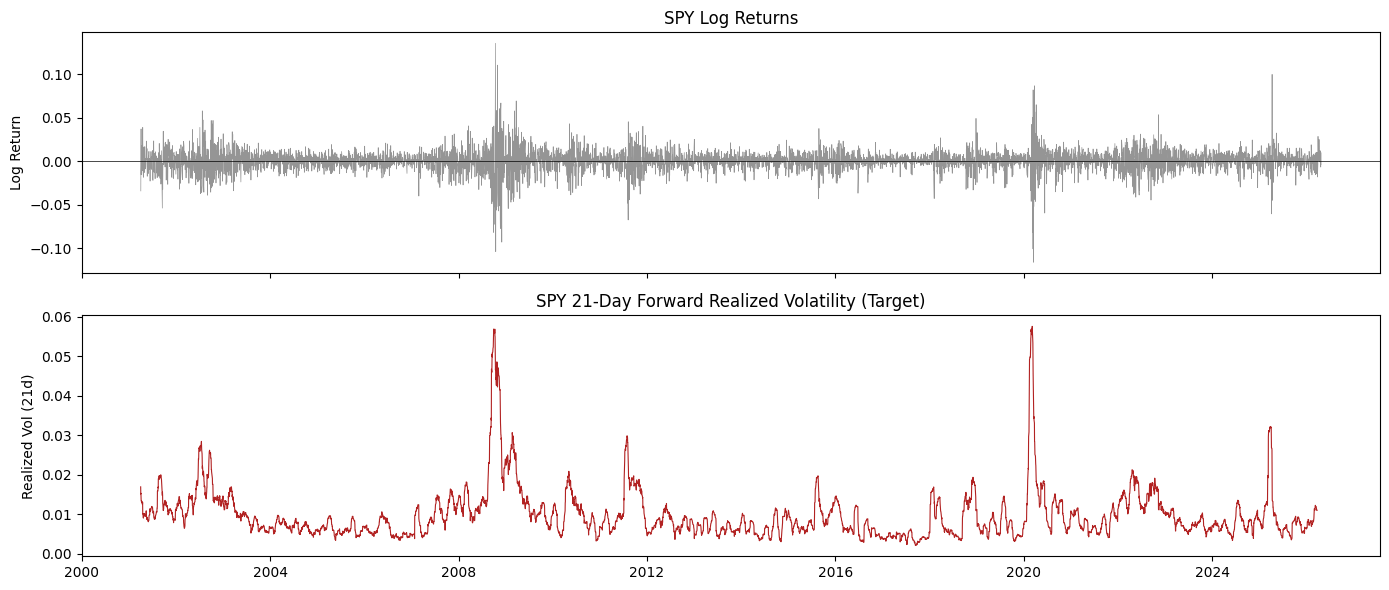

In [7]:
# Quick sanity check: inspect log returns and the target vol
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(
    feat_df.index, feat_df["log_return"], linewidth=0.5, color="dimgray", alpha=0.7
)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("Log Return")
axes[0].set_title("SPY Log Returns")

axes[1].plot(
    feat_df.index, feat_df["realized_vol_21d"], linewidth=0.8, color="firebrick"
)
axes[1].set_ylabel("Realized Vol (21d)")
axes[1].set_title("SPY 21-Day Forward Realized Volatility (Target)")
plt.tight_layout()
plt.show()

In [8]:
# Summary statistics of all engineered features
feat_df.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
Open,6302.0,2.072202e+02,1.622158e+02,4.969150e+01,8.453140e+01,1.377441e+02,2.732440e+02,7.102800e+02
High,6302.0,2.083844e+02,1.630137e+02,5.119070e+01,8.493870e+01,1.386771e+02,2.739128e+02,7.123900e+02
Low,6302.0,2.059560e+02,1.613336e+02,4.906990e+01,8.404830e+01,1.370920e+02,2.720795e+02,7.082200e+02
Close,6302.0,2.072528e+02,1.622529e+02,4.980860e+01,8.443680e+01,1.380107e+02,2.731042e+02,7.112100e+02
Volume,6302.0,1.093569e+08,8.867633e+07,3.303100e+06,5.490652e+07,8.110465e+07,1.351928e+08,8.710263e+08
vix,6301.0,1.964840e+01,8.452800e+00,9.140000e+00,1.386000e+01,1.744000e+01,2.277000e+01,8.269000e+01
vix3m,4624.0,2.164530e+01,7.667700e+00,1.185000e+01,1.620750e+01,1.987000e+01,2.475000e+01,7.298000e+01
bullish,6302.0,3.778000e-01,9.630000e-02,1.584000e-01,3.077000e-01,3.730000e-01,4.409000e-01,7.143000e-01
bearish,6302.0,3.331000e-01,9.770000e-02,8.570000e-02,2.617000e-01,3.203000e-01,3.977000e-01,7.027000e-01
neutral,6302.0,2.892000e-01,7.300000e-02,7.690000e-02,2.360000e-01,2.880000e-01,3.373000e-01,5.286000e-01


In [9]:
feat_df

,Open,High,Low,Close,Volume,vix,vix3m,bullish,bearish,neutral,...,rolling_abs_mean_5,rolling_mean_10,rolling_std_10,rolling_abs_mean_10,rolling_mean_21,rolling_std_21,rolling_abs_mean_21,vix_log_change,vix3m_minus_vix,realized_vol_21d
Date,,,,,,,,,,,,,,,,,,,,,
2001-04-02,74.029741,74.717202,72.438388,72.693001,10561000,31.21,NaN,0.372500,0.274500,0.352900,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016919
2001-04-03,72.553025,72.661236,70.057778,70.267838,12836000,34.72,NaN,0.372500,0.274500,0.352900,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.106577,NaN,0.015104
2001-04-04,70.382385,71.356292,69.573979,70.560616,14884300,34.07,NaN,0.372500,0.274500,0.352900,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.018899,NaN,0.015272
2001-04-05,72.120138,73.514160,71.610903,73.234085,21522800,29.94,NaN,0.351400,0.387400,0.261300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.129222,NaN,0.013965
2001-04-06,72.559381,72.820365,71.330855,72.120171,14937800,31.69,NaN,0.351400,0.387400,0.261300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.056806,NaN,0.013308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-17,706.140015,712.390015,705.760010,710.140015,70661900,17.48,20.51,0.317308,0.427885,0.254808,...,0.008833,0.007956,0.007520,0.008088,0.003514,0.011744,0.009180,-0.025975,3.03,NaN
2026-04-20,708.780029,709.909973,706.140015,708.719971,43546800,18.87,21.24,0.317308,0.427885,0.254808,...,0.007288,0.007284,0.008118,0.007817,0.003536,0.011733,0.009158,0.076516,2.37,NaN
2026-04-21,710.280029,711.280029,702.640015,704.080017,58941400,19.50,21.51,0.317308,0.427885,0.254808,...,0.006180,0.006583,0.009026,0.008430,0.003911,0.011245,0.008783,0.032841,2.01,NaN


## 5. Chronological train / val / test split


In [10]:
from src.features import time_split
from src.utils import describe_splits

# Drop rows with NaN in target or core features before splitting
target_col = f"realized_vol_{VOL_WINDOW}d"
clean_df = feat_df.dropna(subset=["log_return", target_col])
print(f"Rows before dropping NaN: {len(feat_df):,}")
print(f"Rows after  dropping NaN: {len(clean_df):,}")

train, val, test = time_split(clean_df, train_end=TRAIN_END, val_end=VAL_END)
print()
print(describe_splits(train, val, test))

21:38:09 | INFO    | src.features | Split sizes — Train: 3710, Val: 1089, Test: 1481


Rows before dropping NaN: 6,302
Rows after  dropping NaN: 6,280

                 Start         End  Days
Split                                   
Train       2001-04-03  2015-12-31  3710
Validation  2016-01-04  2020-04-30  1089
Test        2020-05-01  2026-03-24  1481


In [11]:
train

,Open,High,Low,Close,Volume,vix,vix3m,bullish,bearish,neutral,...,rolling_abs_mean_5,rolling_mean_10,rolling_std_10,rolling_abs_mean_10,rolling_mean_21,rolling_std_21,rolling_abs_mean_21,vix_log_change,vix3m_minus_vix,realized_vol_21d
Date,,,,,,,,,,,,,,,,,,,,,
2001-04-03,72.553025,72.661236,70.057778,70.267838,12836000,34.72,NaN,0.372500,0.274500,0.352900,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.106577,NaN,0.015104
2001-04-04,70.382385,71.356292,69.573979,70.560616,14884300,34.07,NaN,0.372500,0.274500,0.352900,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.018899,NaN,0.015272
2001-04-05,72.120138,73.514160,71.610903,73.234085,21522800,29.94,NaN,0.351400,0.387400,0.261300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.129222,NaN,0.013965
2001-04-06,72.559381,72.820365,71.330855,72.120171,14937800,31.69,NaN,0.351400,0.387400,0.261300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.056806,NaN,0.013308
2001-04-09,72.565719,73.195893,71.789137,72.922180,9034300,31.91,NaN,0.351400,0.387400,0.261300,...,0.020333,NaN,NaN,NaN,NaN,NaN,NaN,0.006918,NaN,0.013381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-12-24,173.880786,174.396377,173.627214,173.846970,48539600,15.74,19.69,0.263804,0.314928,0.421268,...,0.009837,0.000501,0.013284,0.011412,-0.000560,0.011225,0.009330,0.010859,3.95,0.013004
2015-12-28,173.153826,173.491912,172.376215,173.449661,65899900,16.91,19.68,0.263804,0.314928,0.421268,...,0.006699,0.002229,0.011369,0.009684,-0.000662,0.011231,0.009433,0.071700,2.77,0.013154
2015-12-29,174.548527,175.630421,174.514723,175.300781,92640700,16.08,19.10,0.263804,0.314928,0.421268,...,0.007179,0.002787,0.011655,0.010241,-0.000211,0.011494,0.009884,-0.050329,3.02,0.014138


In [12]:
train.isna().sum()

Open                      0
High                      0
Low                       0
Close                     0
Volume                    0
vix                       0
vix3m                  1676
bullish                   0
bearish                   0
neutral                   0
bull_bear_spread          0
log_return                0
abs_return                0
oc_return                 0
intraday_range            0
log_volume                0
relative_volume_21d      19
rolling_mean_5            4
rolling_std_5             4
rolling_abs_mean_5        4
rolling_mean_10           9
rolling_std_10            9
rolling_abs_mean_10       9
rolling_mean_21          20
rolling_std_21           20
rolling_abs_mean_21      20
vix_log_change            0
vix3m_minus_vix        1676
realized_vol_21d          0
dtype: int64

In [13]:
test

,Open,High,Low,Close,Volume,vix,vix3m,bullish,bearish,neutral,...,rolling_abs_mean_5,rolling_mean_10,rolling_std_10,rolling_abs_mean_10,rolling_mean_21,rolling_std_21,rolling_abs_mean_21,vix_log_change,vix3m_minus_vix,realized_vol_21d
Date,,,,,,,,,,,,,,,,,,,,,
2020-05-01,262.268779,267.186727,258.784846,259.952301,125180000,37.19,37.97,0.305970,0.440299,0.253731,...,0.016190,-0.001352,0.020064,0.016543,0.006608,0.023586,0.019435,0.085277,0.78,0.011764
2020-05-04,258.067842,260.972649,256.587877,260.669312,80873200,35.97,37.00,0.305970,0.440299,0.253731,...,0.013878,0.000701,0.019230,0.015041,0.005653,0.023302,0.018480,-0.033355,1.03,0.011918
2020-05-05,263.491429,265.890636,260.798029,263.077759,79569900,33.61,35.52,0.305970,0.440299,0.253731,...,0.014796,0.004704,0.015796,0.012877,0.006784,0.022843,0.018224,-0.067862,1.91,0.011966
2020-05-06,264.778367,265.164433,260.862389,261.294434,73632600,34.12,35.68,0.305970,0.440299,0.253731,...,0.010988,0.001828,0.014899,0.011362,0.003364,0.018689,0.015453,0.015060,1.56,0.012525
2020-05-07,264.511741,266.377800,263.941816,264.447388,75250400,31.44,34.01,0.236686,0.526627,0.236686,...,0.011515,0.003035,0.015214,0.012554,0.003887,0.018773,0.015975,-0.081803,2.57,0.012525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-18,666.539658,667.895940,659.389203,659.628540,82062600,25.09,26.56,0.319392,0.463878,0.216730,...,0.009556,-0.003520,0.009036,0.007815,-0.001518,0.008079,0.006941,0.114749,1.47,0.011461
2026-03-19,655.180681,661.174323,653.385596,658.002991,111272500,24.06,25.54,0.304000,0.520000,0.176000,...,0.006990,-0.003208,0.009011,0.007503,-0.001874,0.007940,0.006820,-0.041919,1.48,0.011450
2026-03-20,656.510010,656.690002,644.719971,648.570007,163617500,26.78,27.43,0.304000,0.520000,0.176000,...,0.008742,-0.003333,0.009171,0.007628,-0.002436,0.008401,0.007381,0.107105,0.65,0.010974


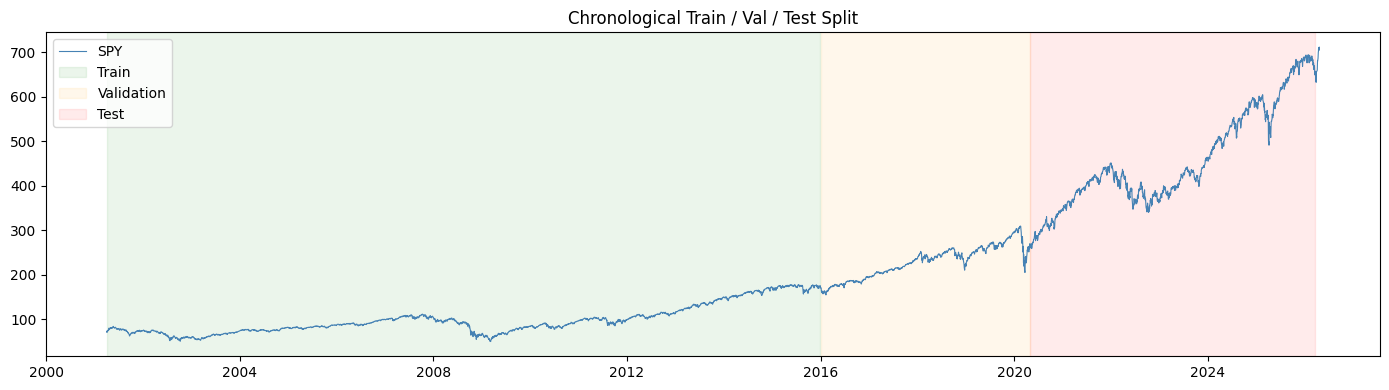

In [14]:
# Visualise the split boundaries on the price chart
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ohlcv.index, ohlcv["Close"], linewidth=0.8, color="steelblue", label="SPY")
ax.axvspan(
    train.index.min(), train.index.max(), alpha=0.08, color="green", label="Train"
)
ax.axvspan(
    val.index.min(), val.index.max(), alpha=0.08, color="orange", label="Validation"
)
ax.axvspan(test.index.min(), test.index.max(), alpha=0.08, color="red", label="Test")
ax.legend()
ax.set_title("Chronological Train / Val / Test Split")
plt.tight_layout()
plt.show()

## 6. Save processed datasets


In [15]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

clean_df.to_parquet(DATA_PROCESSED / "features_all.parquet")
train.to_parquet(DATA_PROCESSED / "train.parquet")
val.to_parquet(DATA_PROCESSED / "val.parquet")
test.to_parquet(DATA_PROCESSED / "test.parquet")

print("Saved:")
for p in DATA_PROCESSED.glob("*.parquet"):
    print(f"  {p}")

Saved:
  /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/processed/test_predictions_gated.parquet
  /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/processed/train.parquet
  /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/processed/test_predictions.parquet
  /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/processed/test.parquet
  /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/processed/val.parquet
  /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/processed/test_predictions_B.parquet
  /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/processed/raw_dataset.parquet
  /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/processed/features_all.parquet
  /Users/zaidt/Desktop/cpsc440/StockVolatilitySight/notebooks/../data/processed/regime_probabilities.parquet


## 7. Feature correlation check


In [16]:
from src.features import drop_correlated_features, variance_inflation_check
from src.utils import plot_correlation_matrix

# All engineered numeric features (exclude raw OHLCV and target)
exclude = ["Open", "High", "Low", "Close", "Volume", target_col]
all_feature_cols = [c for c in clean_df.columns if c not in exclude]

print(f"All feature columns ({len(all_feature_cols)}): {all_feature_cols}")

All feature columns (23): ['vix', 'vix3m', 'bullish', 'bearish', 'neutral', 'bull_bear_spread', 'log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'relative_volume_21d', 'rolling_mean_5', 'rolling_std_5', 'rolling_abs_mean_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_abs_mean_10', 'rolling_mean_21', 'rolling_std_21', 'rolling_abs_mean_21', 'vix_log_change', 'vix3m_minus_vix']


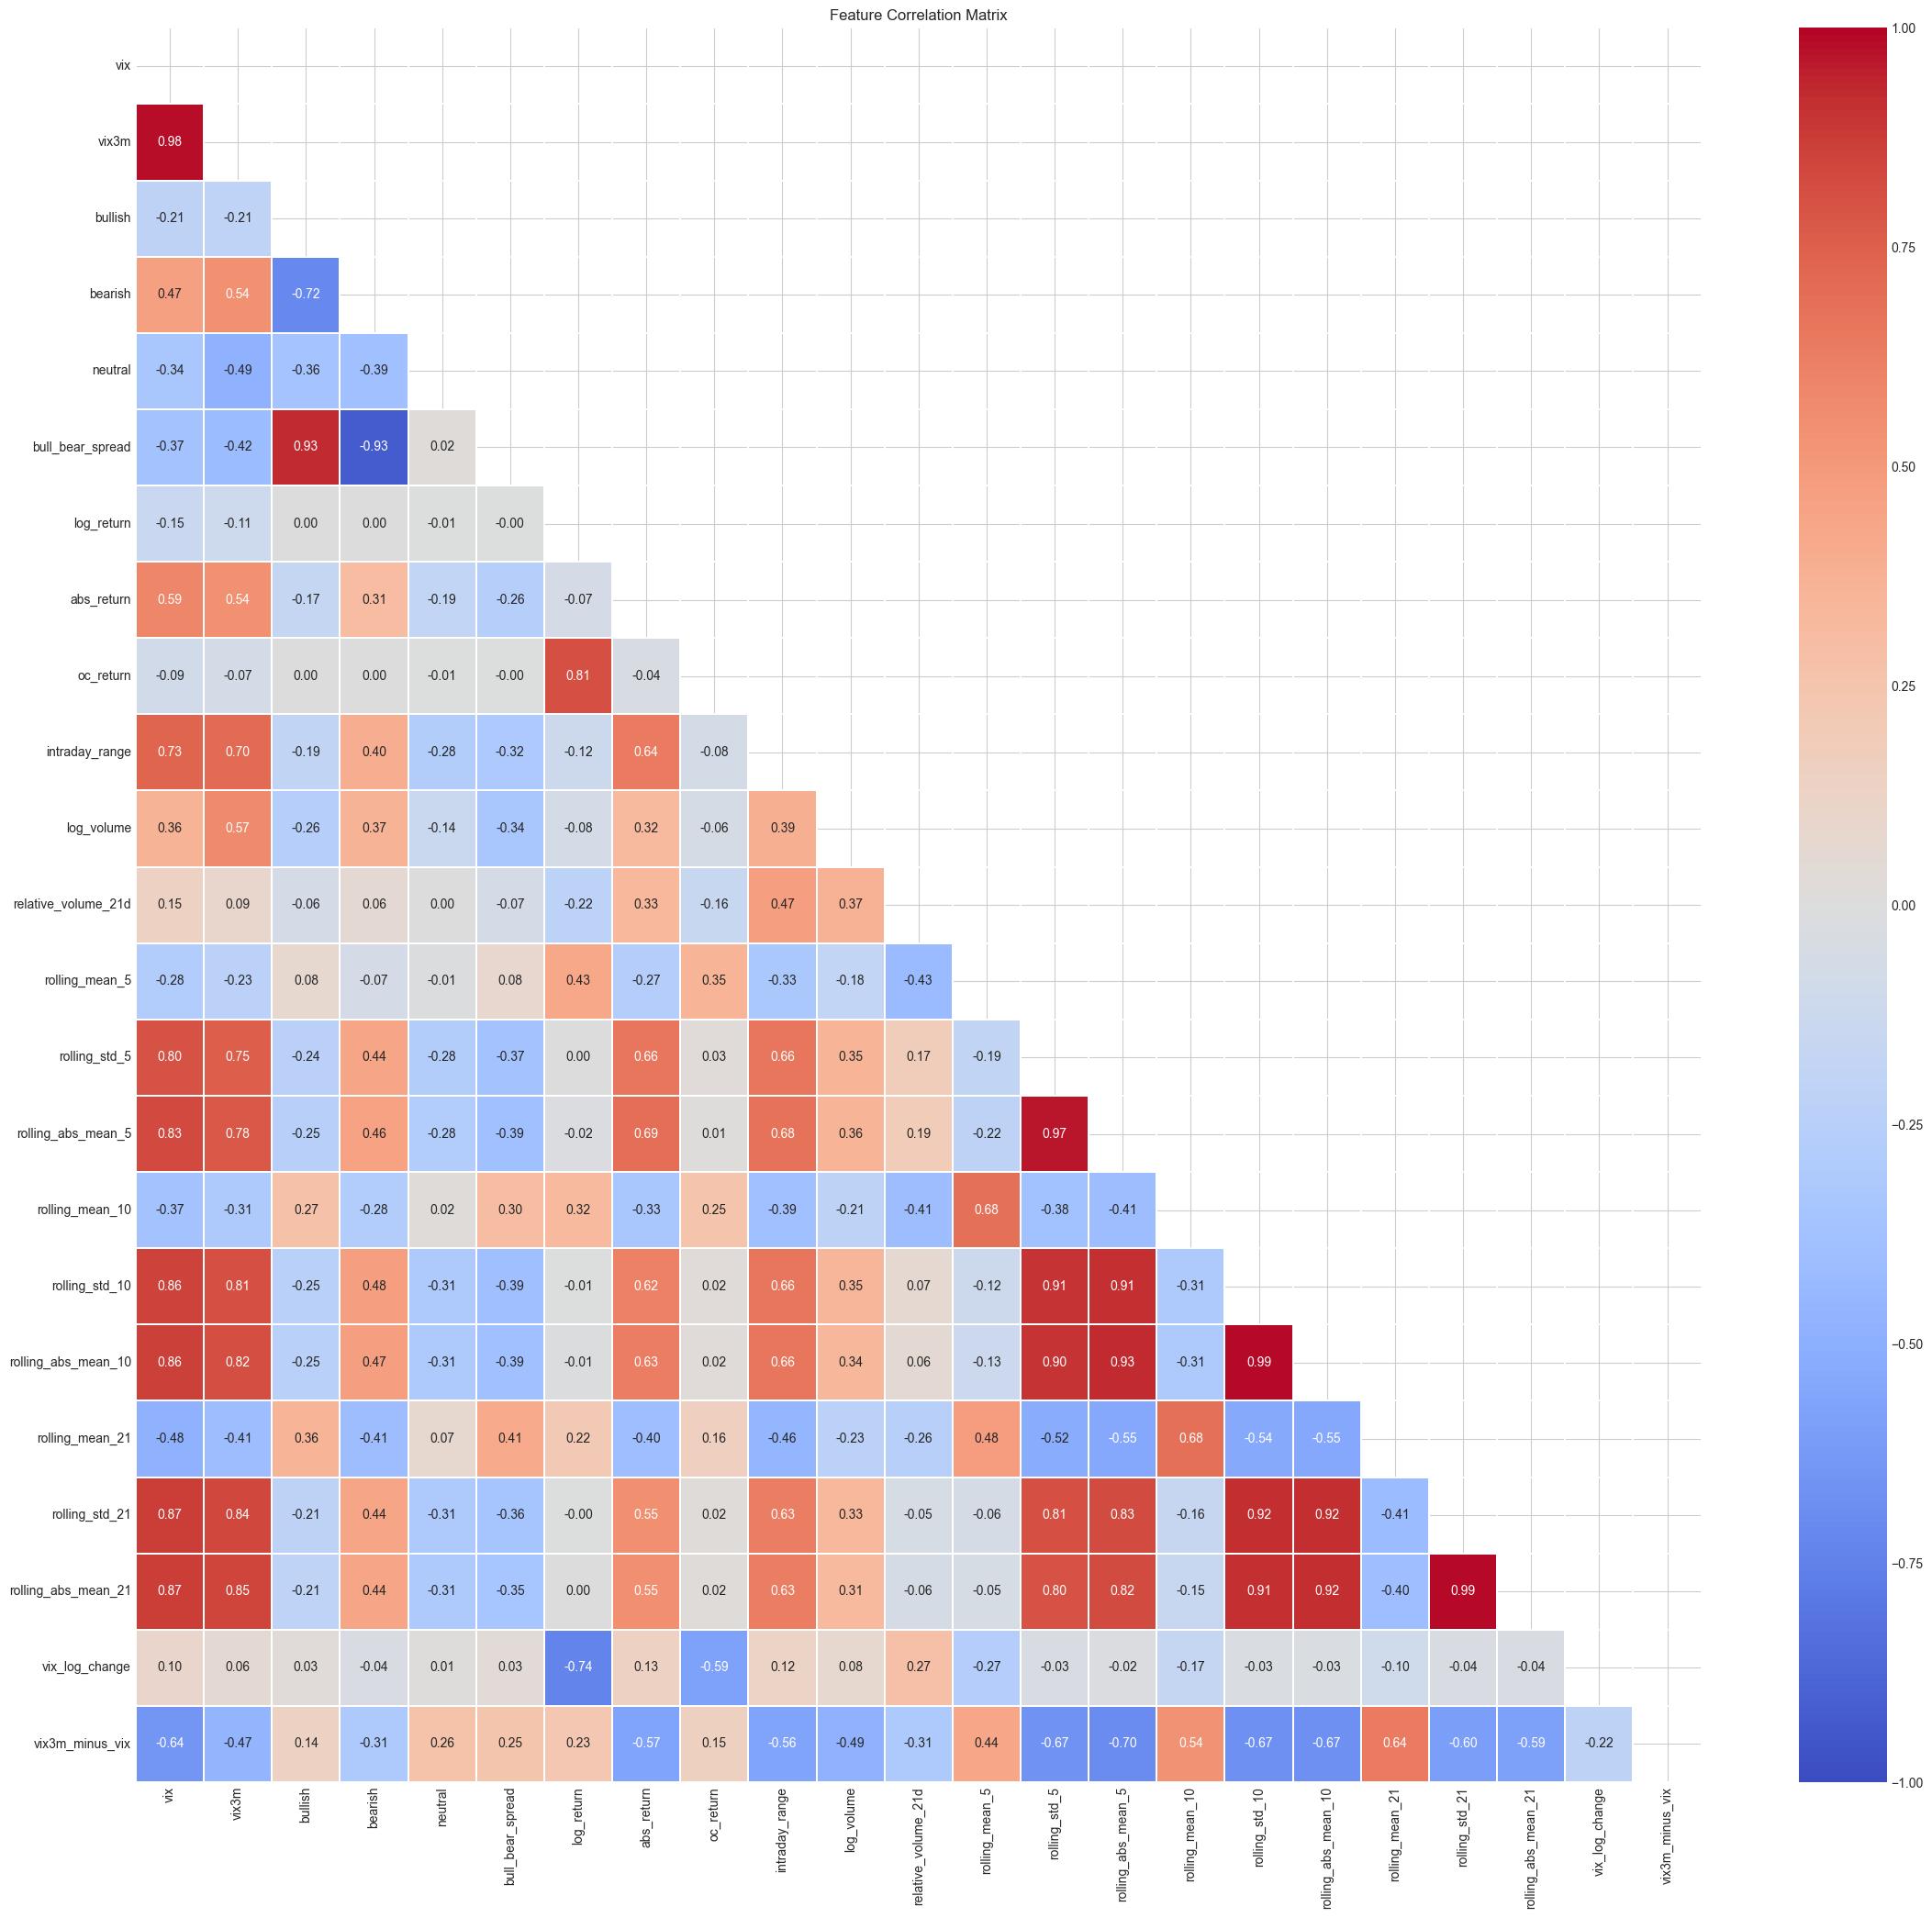

In [17]:
fig = plot_correlation_matrix(clean_df, all_feature_cols)
plt.show()

In [18]:
kept_features = drop_correlated_features(clean_df, all_feature_cols, threshold=0.95)
print(f"Features after correlation pruning ({len(kept_features)}): {kept_features}")

21:38:10 | INFO    | src.features | Dropping correlated features (threshold=0.95): ['vix3m', 'rolling_abs_mean_5', 'rolling_abs_mean_10', 'rolling_abs_mean_21']


Features after correlation pruning (19): ['vix', 'bullish', 'bearish', 'neutral', 'bull_bear_spread', 'log_return', 'abs_return', 'oc_return', 'intraday_range', 'log_volume', 'relative_volume_21d', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_10', 'rolling_std_10', 'rolling_mean_21', 'rolling_std_21', 'vix_log_change', 'vix3m_minus_vix']


In [19]:
vif_df = variance_inflation_check(clean_df, kept_features)
print("VIF scores:")
print(vif_df.to_string(index=False))

21:38:10 | WARNING | src.features | Features with VIF > 10.0 (potential multicollinearity):
            feature         VIF
            bearish         inf
   bull_bear_spread         inf
            bullish         inf
         log_volume 2308.132099
            neutral  272.916459
     intraday_range  202.932049
                vix   49.694686
     rolling_std_10   42.161216
     rolling_std_21   36.056356
relative_volume_21d   22.926305
      rolling_std_5   16.635190


VIF scores:
            feature         VIF
            bearish         inf
   bull_bear_spread         inf
            bullish         inf
         log_volume 2308.132099
            neutral  272.916459
     intraday_range  202.932049
                vix   49.694686
     rolling_std_10   42.161216
     rolling_std_21   36.056356
relative_volume_21d   22.926305
      rolling_std_5   16.635190
    vix3m_minus_vix    4.748834
         log_return    4.315943
         abs_return    3.830053
    rolling_mean_10    3.449949
    rolling_mean_21    2.966695
          oc_return    2.719802
     rolling_mean_5    2.613097
     vix_log_change    2.517558


## Summary

| Item                   | Value |
| ---------------------- | ----- |
| Total trading days (after dropna) | **5,584** |
| Raw engineered feature columns | **15** (before VIF / correlation pruning) |
| Features after correlation pruning | **12** (used for splits & downstream; HMM uses an 11-feature subset per `config`) |
| Train / Val / Test rows | **3,020 / 1,089 / 1,475** (chronological windows; train **2004-01-05 → 2015-12-31**, val 2016–2019, test 2020–2026) |
| Target                 | 21-day forward realized volatility (`realized_vol_21d`) |

Artifacts written under `data/processed/` include `train.parquet`, `val.parquet`, `test.parquet`, `features_all.parquet`, and `regime_probabilities.parquet` (after HMM notebook is run).

Proceed to `02_eda_normality.ipynb` for distribution analysis and normality testing.
